File not found, skipping: /media/hcv530/T71/garment_folding_data/unifolding_folding_from_crumpled/eval_checkpoint_-2/performance.csv


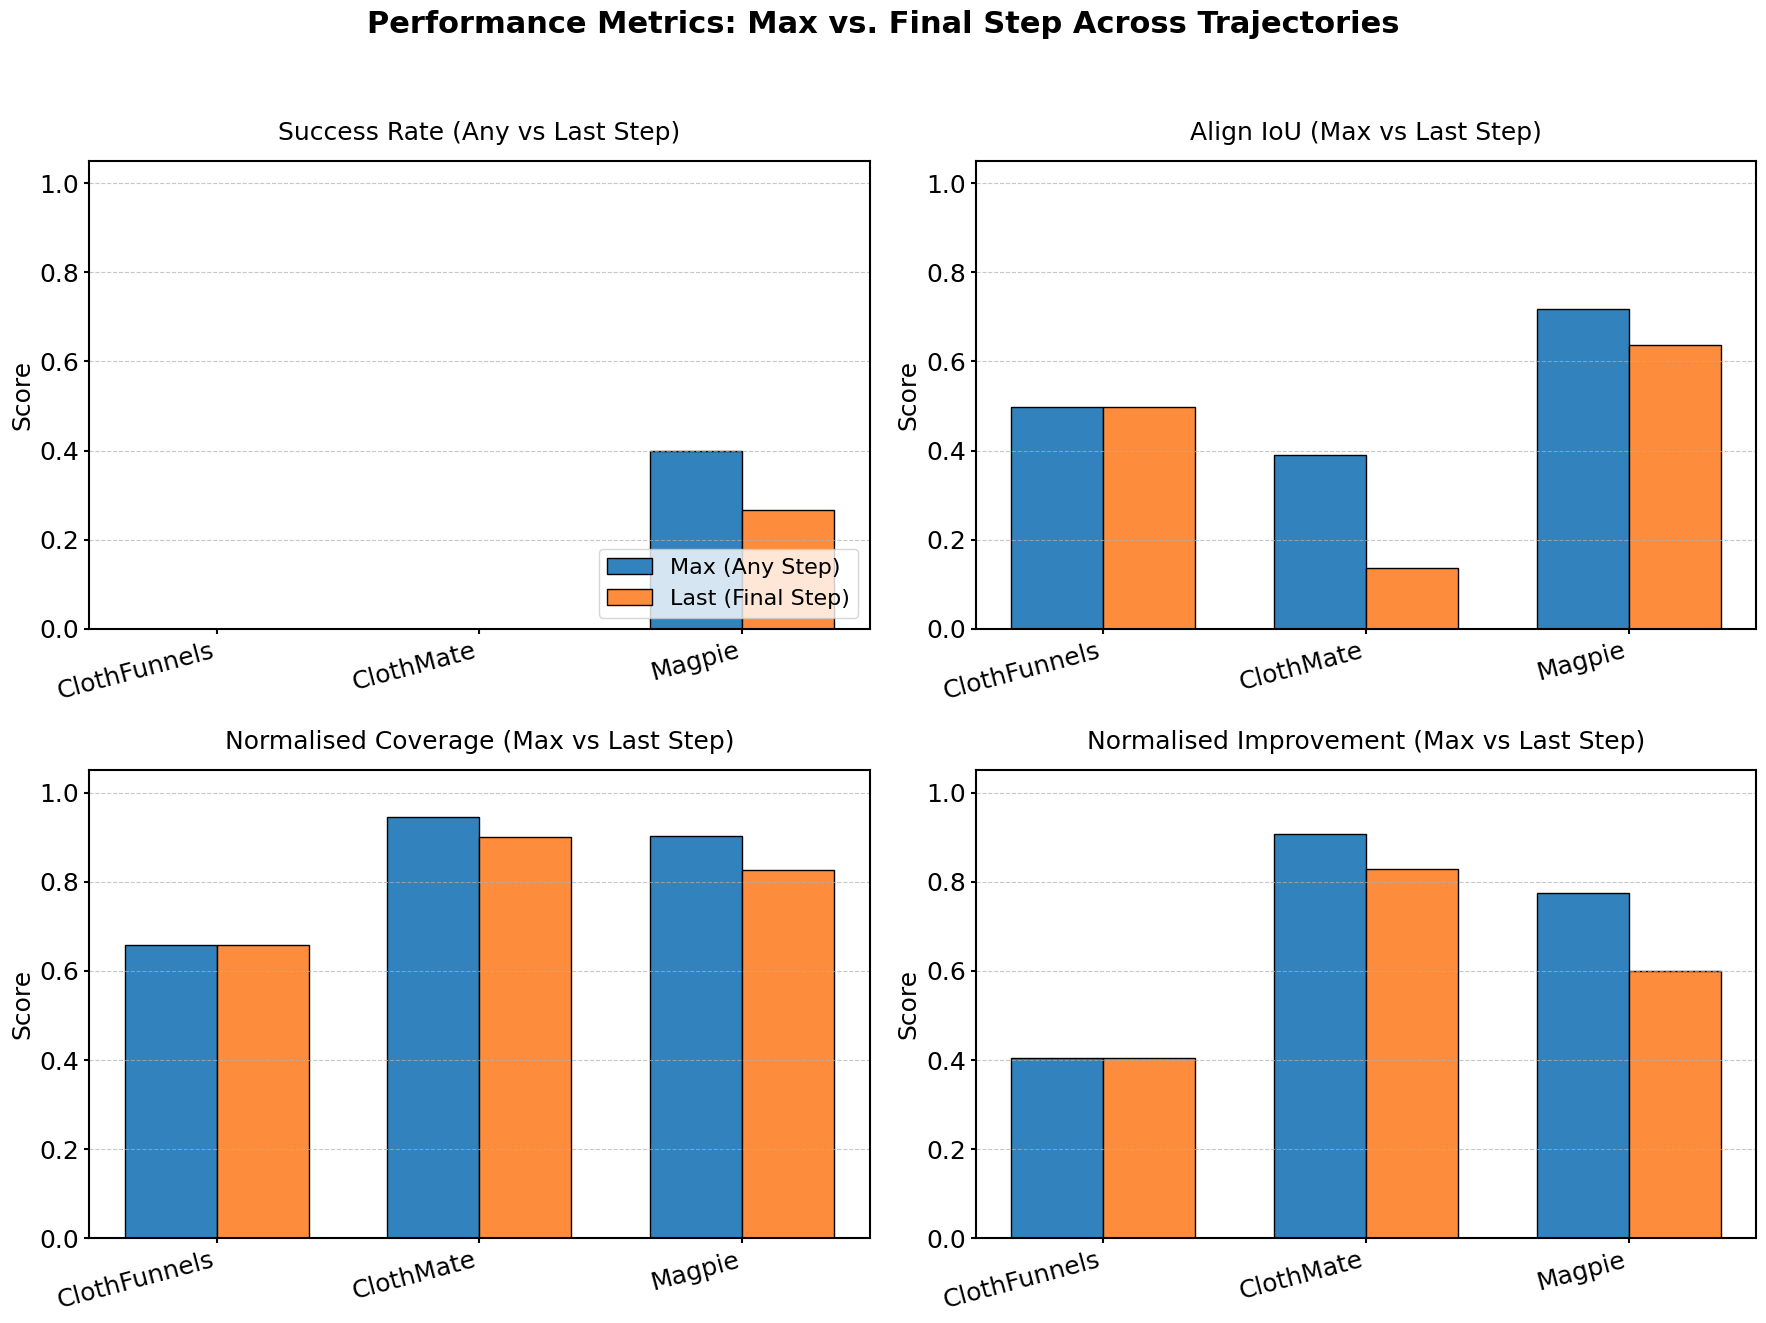

In [ ]:
import os
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# --- 1. Publication-Ready Style Settings ---
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'font.family': 'sans-serif',
    'lines.linewidth': 2.5,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

# Updated to reflect your actual experiments and Max/Last styling
COLORS = {
    # --- Experiment/Method Colors ---
    'ClothFunnels': '#1f77b4',  # Muted Blue
    'ClothMate': '#2ca02c',     # Muted Green
    'UniFolding': '#9467bd',    # Muted Purple
    'Magpie': '#d62728',        # Muted Red
    
    # --- Max vs Last Bar Colors ---
    'Max_Metric': '#3182bd',    # Medium-Dark Blue (from previous Diffusion-100)
    'Last_Metric': '#fd8d3c'    # Bright Orange (from previous Task-Specific LaGarNet)
}

# --- 2. Helper Functions ---
def parse_list(val):
    """Safely converts string lists to Python lists, wraps single numbers, and clips between 0 and 1."""
    parsed_list = []
    
    if pd.isna(val):
        return []
    
    if isinstance(val, list):
        parsed_list = val
        
    elif isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                parsed_list = parsed
            else:
                parsed_list = [parsed] 
        except (ValueError, SyntaxError):
            try:
                parsed_list = [float(val)]
            except ValueError:
                parsed_list = []
                
    elif isinstance(val, (int, float)):
        parsed_list = [val]
        
    clipped_list = []
    for x in parsed_list:
        try:
            clipped_list.append(max(0.0, min(1.0, float(x))))
        except (ValueError, TypeError):
            pass 
            
    return clipped_list

def aggregate_performance_custom(csv_path, iou_thresh=0.8, nc_thresh=0.9, max_steps=20):
    """Calculates Max and Last metrics for SR, IoU, NC, and NI up to max_steps."""
    df = pd.read_csv(csv_path)
    
    df["algn_iou"] = df["evaluation/algn_IoU_to_flattened"].apply(parse_list)
    df["nc"] = df["evaluation/normalised_coverage"].apply(parse_list)
    df["ni"] = df["evaluation/normalised_improvement"].apply(parse_list)
    
    any_step_success = []
    last_step_success = []
    
    for iou_list, nc_list in zip(df["algn_iou"], df["nc"]):
        iou_sliced = iou_list[:max_steps] if max_steps is not None else iou_list
        nc_sliced = nc_list[:max_steps] if max_steps is not None else nc_list
        
        # Max (Any-step) Success
        if any((i > iou_thresh and n > nc_thresh) for i, n in zip(iou_sliced, nc_sliced)):
            any_step_success.append(1)
        else:
            any_step_success.append(0)
            
        # Last-step Success
        if len(iou_sliced) > 0 and len(nc_sliced) > 0:
            if iou_sliced[-1] > iou_thresh and nc_sliced[-1] > nc_thresh:
                last_step_success.append(1)
            else:
                last_step_success.append(0)
        else:
            last_step_success.append(0)

    def safe_max(lst):
        sliced = lst[:max_steps] if max_steps is not None else lst
        return np.max(sliced) if len(sliced) > 0 else 0.0
        
    def safe_last(lst):
        sliced = lst[:max_steps] if max_steps is not None else lst
        return sliced[-1] if len(sliced) > 0 else 0.0

    max_iou = [safe_max(x) for x in df["algn_iou"]]
    max_nc = [safe_max(x) for x in df["nc"]]
    max_ni = [safe_max(x) for x in df["ni"]]
    
    last_iou = [safe_last(x) for x in df["algn_iou"]]
    last_nc = [safe_last(x) for x in df["nc"]]
    last_ni = [safe_last(x) for x in df["ni"]]

    return {
        "SR_max_mean": np.mean(any_step_success),
        "IoU_max_mean": np.mean(max_iou),
        "NC_max_mean": np.mean(max_nc),
        "NI_max_mean": np.mean(max_ni),
        
        "SR_last_mean": np.mean(last_step_success),
        "IoU_last_mean": np.mean(last_iou),
        "NC_last_mean": np.mean(last_nc),
        "NI_last_mean": np.mean(last_ni),
    }

# --- 3. Processing and Plotting Function ---
def process_and_plot_task(data_dir, experiments, task_title):
    """Processes CSVs for a given list of experiments and plots the grouped bar chart."""
    rows = []
    for exp in experiments:
        path = os.path.join(data_dir, exp["name"], exp["check"], "performance.csv")
        if os.path.exists(path):
            m = aggregate_performance_custom(path, iou_thresh=0.8, nc_thresh=0.9)
            m["experiment"] = exp["label"]
            rows.append(m)
        else:
            print(f"[{task_title}] File not found, skipping: {path}")

    # Fallback fake data for testing
    if not rows:
        print(f"[{task_title}] Warning: No files found. Using dummy data for visualization testing.")
        for exp in experiments:
            rows.append({
                "experiment": exp["label"],
                "SR_max_mean": np.random.uniform(0.6, 0.9), "SR_last_mean": np.random.uniform(0.4, 0.7),
                "IoU_max_mean": np.random.uniform(0.7, 0.95), "IoU_last_mean": np.random.uniform(0.5, 0.8),
                "NC_max_mean": np.random.uniform(0.8, 0.98), "NC_last_mean": np.random.uniform(0.6, 0.9),
                "NI_max_mean": np.random.uniform(0.5, 0.8), "NI_last_mean": np.random.uniform(0.3, 0.6)
            })

    results_df = pd.DataFrame(rows)

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle(f'{task_title} Metrics: Max vs. Final Step', fontsize=22, fontweight='bold', y=0.95)

    metrics_to_plot = [
        ('SR_max_mean', 'SR_last_mean', 'Success Rate (Any vs Last Step)'),
        ('IoU_max_mean', 'IoU_last_mean', 'Align IoU (Max vs Last Step)'),
        ('NC_max_mean', 'NC_last_mean', 'Normalised Coverage (Max vs Last Step)'),
        ('NI_max_mean', 'NI_last_mean', 'Normalised Improvement (Max vs Last Step)')
    ]

    x = np.arange(len(results_df['experiment']))
    width = 0.35

    color_max = COLORS['Max_Metric']
    color_last = COLORS['Last_Metric']

    for i, ax in enumerate(axes.flatten()):
        max_col, last_col, title = metrics_to_plot[i]
        
        ax.bar(x - width/2, results_df[max_col], width, label='Max (Any Step)', color=color_max, edgecolor='black')
        ax.bar(x + width/2, results_df[last_col], width, label='Last (Final Step)', color=color_last, edgecolor='black')
        
        ax.set_title(title, pad=15)
        ax.set_ylabel('Score')
        ax.set_xticks(x)
        ax.set_xticklabels(results_df['experiment'], rotation=15, ha='right')
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        if i == 0: 
            ax.legend(loc='lower right')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


# --- 4. Main Execution ---

data_dir = "/media/hcv530/T71/garment_folding_data"

# Task 1: Canonicalisation Alignment
canon_experiments = [
    {"name": "cloth_funnel_longsleeve_canon_align_from_crumpled", "label": "ClothFunnels", "check": "eval_checkpoint_-1"},
    {"name": "clothmate_longsleeve_canon_align_from_crumpled", "label": "ClothMate", "check": "eval_checkpoint_True"},
    {"name": "unifolding_canon_align_from_crumpled", "label": "UniFolding", "check": "eval_checkpoint_-2"},
    # You can add Magpie for canon here if you have it
]

# Task 2: Central Alignment
# (Update the dummy paths for ClothFunnels, ClothMate, and UniFolding below to match your actual central alignment foldernames)
central_experiments = [
    {"name": "cloth_funnel_ctr_align_longsleeve", "label": "ClothFunnels", "check": "eval_checkpoint_-1"}, 
    {"name": "clothmate_ctr_align_longsleeve", "label": "ClothMate", "check": "eval_checkpoint_True"},
    {"name": "unifolding_ctr_align_longsleeve", "label": "UniFolding", "check": "eval_checkpoint_-2"},
    {"name": "magpie_ctr_align_longsleeve_p4_v17", "label": "Magpie", "check": "eval_checkpoint_100000"},
]

# Generate plot for Canonicalisation Task
process_and_plot_task(data_dir, canon_experiments, task_title="Canonicalisation Alignment")

# Generate plot for Central Alignment Task
process_and_plot_task(data_dir, central_experiments, task_title="Central Alignment")